Quantidade de linhas e colunas:
(891, 12)

Quantidade de linhas:
891

Quantidade de colunas:
12

Tipo de dado de cada variável:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Resumo estatístico das variáveis numéricas:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38

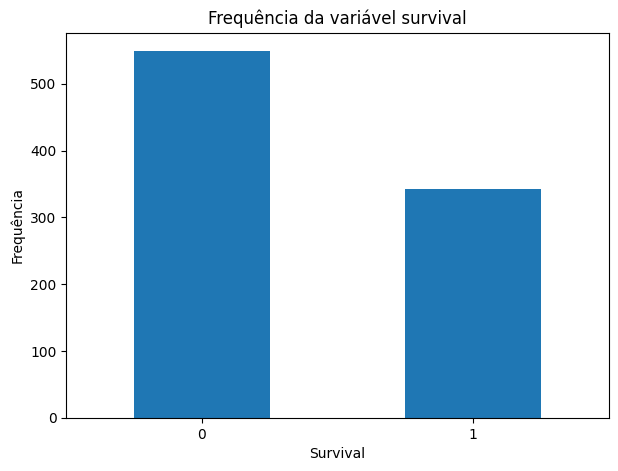


O gráfico de barras foi escolhido porque a variável survival é categórica/binária, com poucas categorias.

Quantidade de pessoas que sobreviveram:
342

Classe mais frequente:
3

Tabela de frequência entre sex e survival:
Survived    0    1
Sex               
female     81  233
male      468  109


<Figure size 800x500 with 0 Axes>

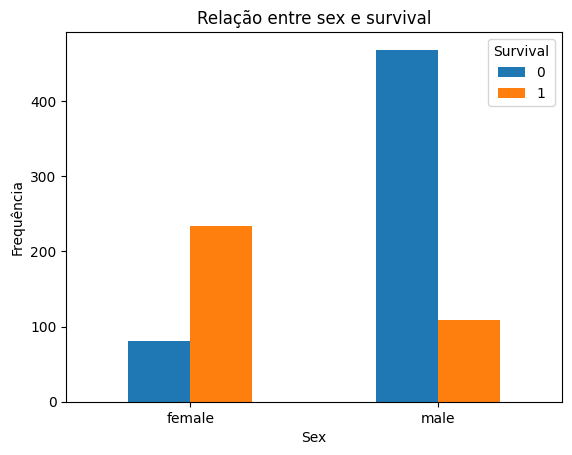


Taxa de sobrevivência por sexo (%):
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Mulheres sobreviveram mais que homens.

Resumo estatístico da variável idade:
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


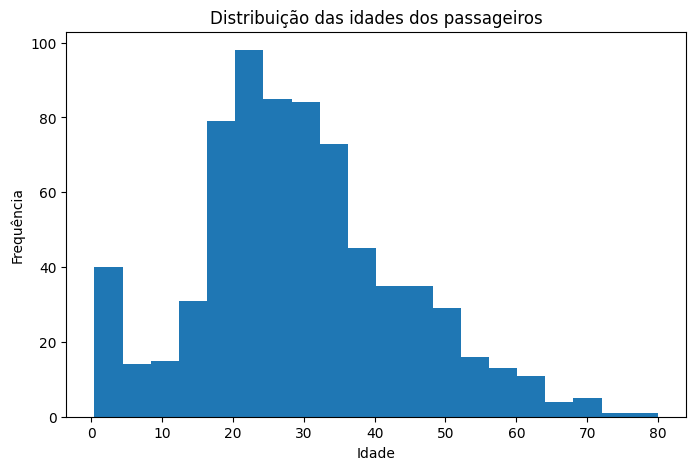


Média da idade:
29.69911764705882

Mediana da idade:
28.0

A distribuição das idades parece assimétrica à direita.

A maioria dos passageiros era jovem ou adulta jovem.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("train.csv")

print("Quantidade de linhas e colunas:")
print(df.shape)

print("\nQuantidade de linhas:")
print(df.shape[0])

print("\nQuantidade de colunas:")
print(df.shape[1])

print("\nTipo de dado de cada variável:")
print(df.dtypes)

print("\nResumo estatístico das variáveis numéricas:")
print(df.describe())

print("\nResumo estatístico das variáveis categóricas:")
print(df.describe(include="str"))


if "survival" in df.columns:
    survival_col = "survival"
elif "Survived" in df.columns:
    survival_col = "Survived"
elif "survived" in df.columns:
    survival_col = "survived"
else:
    raise ValueError("A variável survival não foi encontrada.")


frequencia_survival = df[survival_col].value_counts().sort_index()

print("\nTabela de frequência da variável survival:")
print(frequencia_survival)

plt.figure(figsize=(7, 5))
frequencia_survival.plot(kind="bar")
plt.title("Frequência da variável survival")
plt.xlabel("Survival")
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.show()

print("\nO gráfico de barras foi escolhido porque a variável survival é categórica/binária, com poucas categorias.")


sobreviventes = (df[survival_col] == 1).sum()

print("\nQuantidade de pessoas que sobreviveram:")
print(sobreviventes)


if "Pclass" in df.columns:
    classe_mais_frequente = df["Pclass"].mode()[0]
    print("\nClasse mais frequente:")
    print(classe_mais_frequente)
else:
    print("\nA variável Pclass não foi encontrada.")


if "sex" in df.columns:
    sex_col = "sex"
elif "Sex" in df.columns:
    sex_col = "Sex"
else:
    raise ValueError("A variável sex não foi encontrada.")


tabela_sex_survival = pd.crosstab(df[sex_col], df[survival_col])

print("\nTabela de frequência entre sex e survival:")
print(tabela_sex_survival)

plt.figure(figsize=(8, 5))
tabela_sex_survival.plot(kind="bar")
plt.title("Relação entre sex e survival")
plt.xlabel("Sex")
plt.ylabel("Frequência")
plt.xticks(rotation=0)
plt.legend(title="Survival")
plt.show()


taxa_sobrevivencia_sex = df.groupby(sex_col)[survival_col].mean() * 100

print("\nTaxa de sobrevivência por sexo (%):")
print(taxa_sobrevivencia_sex)

if "female" in taxa_sobrevivencia_sex.index and "male" in taxa_sobrevivencia_sex.index:
    if taxa_sobrevivencia_sex["female"] > taxa_sobrevivencia_sex["male"]:
        print("\nMulheres sobreviveram mais que homens.")
    elif taxa_sobrevivencia_sex["female"] < taxa_sobrevivencia_sex["male"]:
        print("\nHomens sobreviveram mais que mulheres.")
    else:
        print("\nHomens e mulheres tiveram a mesma taxa de sobrevivência.")


if "age" in df.columns:
    age_col = "age"
elif "Age" in df.columns:
    age_col = "Age"
else:
    raise ValueError("A variável age não foi encontrada.")


print("\nResumo estatístico da variável idade:")
print(df[age_col].describe())

plt.figure(figsize=(8, 5))
df[age_col].dropna().plot(kind="hist", bins=20)
plt.title("Distribuição das idades dos passageiros")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()


media_idade = df[age_col].mean()
mediana_idade = df[age_col].median()

print("\nMédia da idade:")
print(media_idade)

print("\nMediana da idade:")
print(mediana_idade)

if media_idade > mediana_idade:
    print("\nA distribuição das idades parece assimétrica à direita.")
elif media_idade < mediana_idade:
    print("\nA distribuição das idades parece assimétrica à esquerda.")
else:
    print("\nA distribuição das idades parece aproximadamente simétrica.")

if mediana_idade < 40:
    print("\nA maioria dos passageiros era jovem ou adulta jovem.")
else:
    print("\nA maioria dos passageiros era adulta mais velha ou idosa.")